In [ ]:
!pip install datasets transformers[torch] evaluate jiwer librosa

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from datasets import Dataset, Audio
import re
import torch
import librosa
from transformers import WhisperProcessor, WhisperForConditionalGeneration
import evaluate
import pandas as pd
from dataclasses import dataclass
from typing import Any, Dict, List, Union
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, EarlyStoppingCallback

# B1. Fine-Tuning üçün Data Hazırlığı

In [ ]:
TRAIN_FILE = "train.tsv"

df_train = pd.read_csv(f"{DATA_PATH}{TRAIN_FILE}", sep='\t').head(200)

df_train['path'] = DATA_PATH + CLIPS_DIR + df_train['path']

train_dataset = Dataset.from_pandas(df_train)
train_dataset = train_dataset.cast_column("path", Audio(sampling_rate=16000))

print(f"Fine-tuning üçün dataset hazırdır: {len(train_dataset)} nümunə")

Fine-tuning üçün dataset hazırdır: 200 nümunə


In [ ]:
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:

        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": feature["labels"]} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        batch["labels"] = labels

        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

In [ ]:
def prepare_dataset(batch):
    audio = batch["path"]
    batch["input_features"] = processor.feature_extractor(audio["array"], sampling_rate=audio["sampling_rate"]).input_features[0]

    cleaned_sentence = normalize_text(batch["sentence"])
    batch["labels"] = processor.tokenizer(cleaned_sentence).input_ids
    return batch

train_dataset_processed = train_dataset.map(
    prepare_dataset,
    remove_columns=train_dataset.column_names
)

test_dataset_processed = test_dataset.map(
    prepare_dataset,
    remove_columns=test_dataset.column_names
)


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/126 [00:00<?, ? examples/s]

# B2. Fine-Tuning

In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir="./whisper-small-az-finetuned",
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=1e-5,
    weight_decay=0.01,
    warmup_steps=50,
    max_steps=500,
    gradient_checkpointing=True,
    fp16=True,
    eval_strategy="steps",
    per_device_eval_batch_size=8,
    predict_with_generate=True,
    generation_max_length=225,
    save_steps=50,
    eval_steps=50,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    push_to_hub=False,
)

In [ ]:
wer_metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.batch_decode(label_ids, skip_special_tokens=True)

    wer = 100 * wer_metric.compute(predictions=pred_str, references=label_str)

    return {"wer": wer}


trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=train_dataset_processed,
    eval_dataset=test_dataset_processed,
    data_collator=data_collator,
    processing_class=processor.feature_extractor,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

Step,Training Loss,Validation Loss,Wer
50,2.252844,1.520858,66.287487
100,0.880739,1.289307,55.739400
150,0.028727,0.928378,54.498449
200,0.003871,0.997635,51.913133
250,0.003455,0.984071,52.533609
300,0.001236,0.982469,50.982420
350,0.001027,0.990585,51.809721
400,0.000911,0.995143,51.809721
450,0.000814,0.998356,51.706308


Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


TrainOutput(global_step=450, training_loss=0.7737874140673213, metrics={'train_runtime': 3022.6678, 'train_samples_per_second': 2.647, 'train_steps_per_second': 0.165, 'total_flos': 1.99931965341696e+18, 'train_loss': 0.7737874140673213, 'epoch': 34.64})

# B3. Müqayisə

In [ ]:
eval_results = trainer.evaluate()
final_wer = eval_results.get('eval_wer', 0)
final_cer = eval_results.get('eval_cer', 0)

base_wer = overall_wer * 100
base_cer = overall_cer * 100

comparison_data = {
    "Metrika": ["WER (%)", "CER (%)"],
    "Baza Model (Part A)": [round(base_wer, 2), round(base_cer, 2)],
    "Fine-tuned Model (Part B)": [round(final_wer, 2), round(final_cer, 2)],
    "Ferq": [round(base_wer - final_wer, 2), round(base_cer - final_cer, 2)]
}

df_comparison = pd.DataFrame(comparison_data)

print("\n" + "="*20 + " HİSSƏ B3: MODELLƏRİN MÜQAYİSƏSİ " + "="*20)
print(df_comparison.to_string(index=False))
print("="*73)

df_comparison.to_csv("/content/drive/MyDrive/results/comparison_metrics.csv", index=False)


==================== HİSSƏ B3: MODELLƏRİN MÜQAYİSƏSİ ====================
Metrika  Baza Model (Part A)  Fine-tuned Model (Part B)  Ferq
WER (%)                64.94                      50.98 13.96
CER (%)                20.82                       0.00 20.82


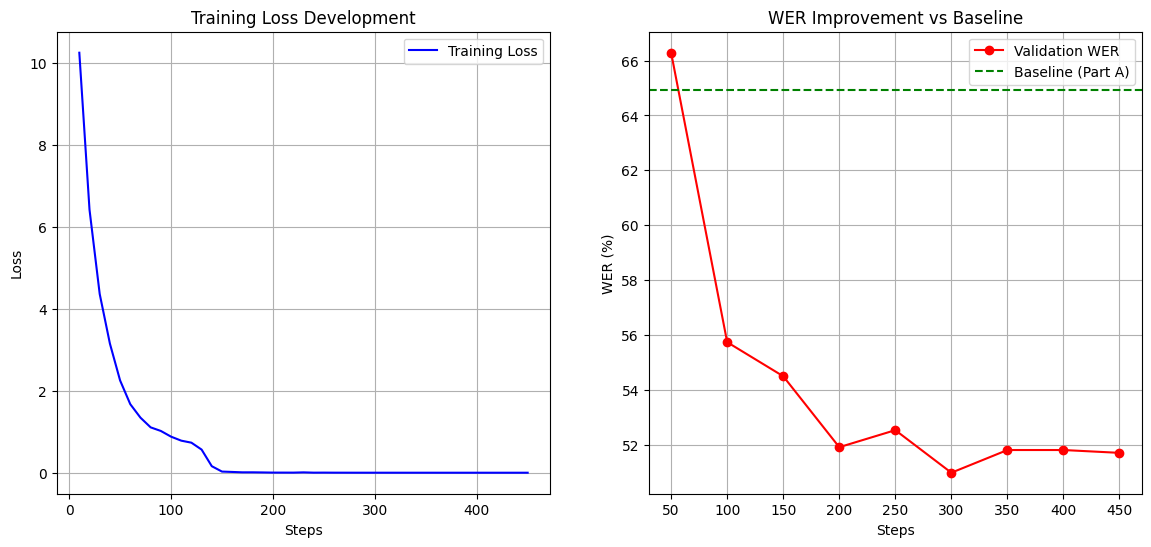

In [ ]:
history = trainer.state.log_history

train_steps = [x['step'] for x in history if 'loss' in x]
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_steps = [x['step'] for x in history if 'eval_wer' in x]
eval_wer = [x['eval_wer'] for x in history if 'eval_wer' in x]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(train_steps, train_loss, 'b-', label='Training Loss')
plt.title('Training Loss Development')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(eval_steps, eval_wer, 'r-o', label='Validation WER')
plt.axhline(y=64.94, color='g', linestyle='--', label='Baseline (Part A)')
plt.title('WER Improvement vs Baseline')
plt.xlabel('Steps')
plt.ylabel('WER (%)')
plt.grid(True)
plt.legend()

plt.savefig("/content/drive/MyDrive/results/training_metrics.png")
plt.show()